# ARGUS-FEDER — How does helium affect deuterium retention in tungsten?

This notebook shows **ARGUS**, a notebook-native AI agent, working on one
question and three follow-ups. The questions are typed in plain English into an
`%%ask` cell. The agent decides what to look up, writes and runs its own code,
and reports back.

**Who wrote what.** This introduction and the short note above each question are
written by us, at SDSC. Everything inside and below an `%%ask` cell is the
agent's own: the steps it took, the code it wrote, the figures and the answer.
The questions themselves were written with Greg Sinclair and Amy Zheng, whose
group produced the data.

## The question

A burning plasma makes helium as well as consuming hydrogen isotopes, so the
tungsten facing one is tungsten that already carries a helium layer. Whether
that layer then holds more fuel or less is a first-order question for a reactor,
because deuterium and tritium held in the wall are both a safety limit and an
economic one.

The delivery this notebook works from was built to ask exactly that. Tungsten
coupons were pre-exposed to helium in the PISCES-A linear device at two
temperatures, mounted on the DiMES probe alongside coupons that were not, and
exposed together to real DIII-D discharges. Retention was measured afterwards by
three laboratory techniques.

The question is asked plainly first. The follow-ups then press on the two places
where a single number could mislead: which technique produced it, and which
plasma the coupon saw. The last question asks what the data cannot support.


In [ ]:
%reset

## 1 — The question, as asked

Put plainly, the way it would be asked in a meeting, with no constraint on how
it should be answered.


I'll research this question using the d3d-materials skill, which covers plasma-facing-component sample data including retention measurements. Let me plan first.

Reading the skill instructions now.

The skill is in the Learnings list, so I'll read its Learnings.md before writing any code.

Learnings noted — quantity names are provider-specific, so I'll discover them first rather than guessing keywords. Writing a discovery script now.

Running the discovery script.

...

All outputs are present. Let me verify the CSV contents that back the report numbers.

All artifacts verified. One more quick pull — LAMS He profiles for the DIII-D-exposed coupons, to state the He-retention side accurately.

Closing self-audit: I had three edit-and-retry cycles. Two are recorded in Learnings; the `show_images` → `save_figure` one is not yet. Recording it now.

Let me verify the plotting script's actual content so the report describes the chart honestly.

# Effect of helium on deuterium retention in tungsten

**Short answer:** In this experiment it depends on the temperature of the helium pre-exposure and on the plasma regime — helium is not a uniform suppressor. He pre-exposure at **800 K cut D retention in H-mode DIII-D plasma to roughly a third to a half** of the no-He control (NRA 0.31×, ERDA 0.58×). At **600 K, and in L-mode generally, He pre-exposure *increased* D retention** (NRA 1.11×–1.85×, ERDA 1.27×–1.63× vs the same-regime controls). So He only reduces D uptake in the combination "high-temperature fuzz-forming pre-exposure + H-mode plasma"; elsewhere in this design it enhances it.

## The experiment (delivery `2026-09-04_amy`, 9 tungsten coupons)

All coupons were heat-treated identically (1373 K, 3600 s) before any exposure. The design then splits cleanly (one sample per cell, **no replication** ):

| Sample | PISCES-A He pre-exposure | DIII-D D exposure |
|---|---|---|
| W-pristine | none | none |
| W-He800 / W-He600 | He plasma, 800 K / 600 K | none |
| W-DH / W-DL | none | H-mode / L-mode |
| W-He800-DH, W-He600-DH | He, 800 K / 600 K | H-mode (shots 185258–185260, 185265–185266) |
| W-He800-DL, W-He600-DL | He, 800 K / 600 K | L-mode (shots 185261–185264) |

He pre-exposure conditions (two *different* campaigns, so temperature is confounded with fluence and duration): 800 K — 1.2×10²⁵ He m⁻², 70 eV impact energy, 480 s; 600 K — 1.0×10²⁵ He m⁻², 70 eV, 4260 s. DIII-D D exposure: H-mode 6.7×10²² m⁻² at 150 eV, 0.72 MW m⁻²; L-mode 7.8×10²² m⁻² at 175 eV, 0.47 MW m⁻².

## Retained deuterium, per level of the He treatment

The provider ranks **NRA as the most trustworthy** method, ERDA close behind, LAMS as indicative only (large uncertainties). NRA totals below sum the two measured bands (0–0.5 µm + 0.5–3 µm); ERDA measures the near-surface inventory.

| Comparison | Control (no He) | + He 800 K | + He 600 K |
|---|---|---|---|
| H-mode, NRA total | 2.10×10¹⁵ at cm⁻² | 6.52×10¹⁴ (**0.31×** ) | 2.46×10¹⁵ (**1.17×** ) |
| H-mode, ERDA | 1.16×10¹⁵ ± 0.06 | 6.68×10¹⁴ ± 0.05 (**0.58×** ) | 1.47×10¹⁵ ± 0.06 (**1.27×** ) |
| L-mode, NRA total | 2.66×10¹⁵ | 2.96×10¹⁵ (**1.11×** ) | 4.92×10¹⁵ (**1.85×** ) |
| L-mode, ERDA | 1.47×10¹⁵ ± 0.07 | 2.00×10¹⁵ ± 0.08 (**1.36×** ) | 2.40×10¹⁵ ± 0.09 (**1.63×** ) |

Both methods agree on the sign of each of the four comparisons, which is the substantive point: **the only suppressive cell is He-800 K + H-mode** ; the other three He-pre-exposed cells retained *more* D than their controls (computed ratio range 0.31–1.85 over the four NRA comparisons, 0.58–1.63 over ERDA).


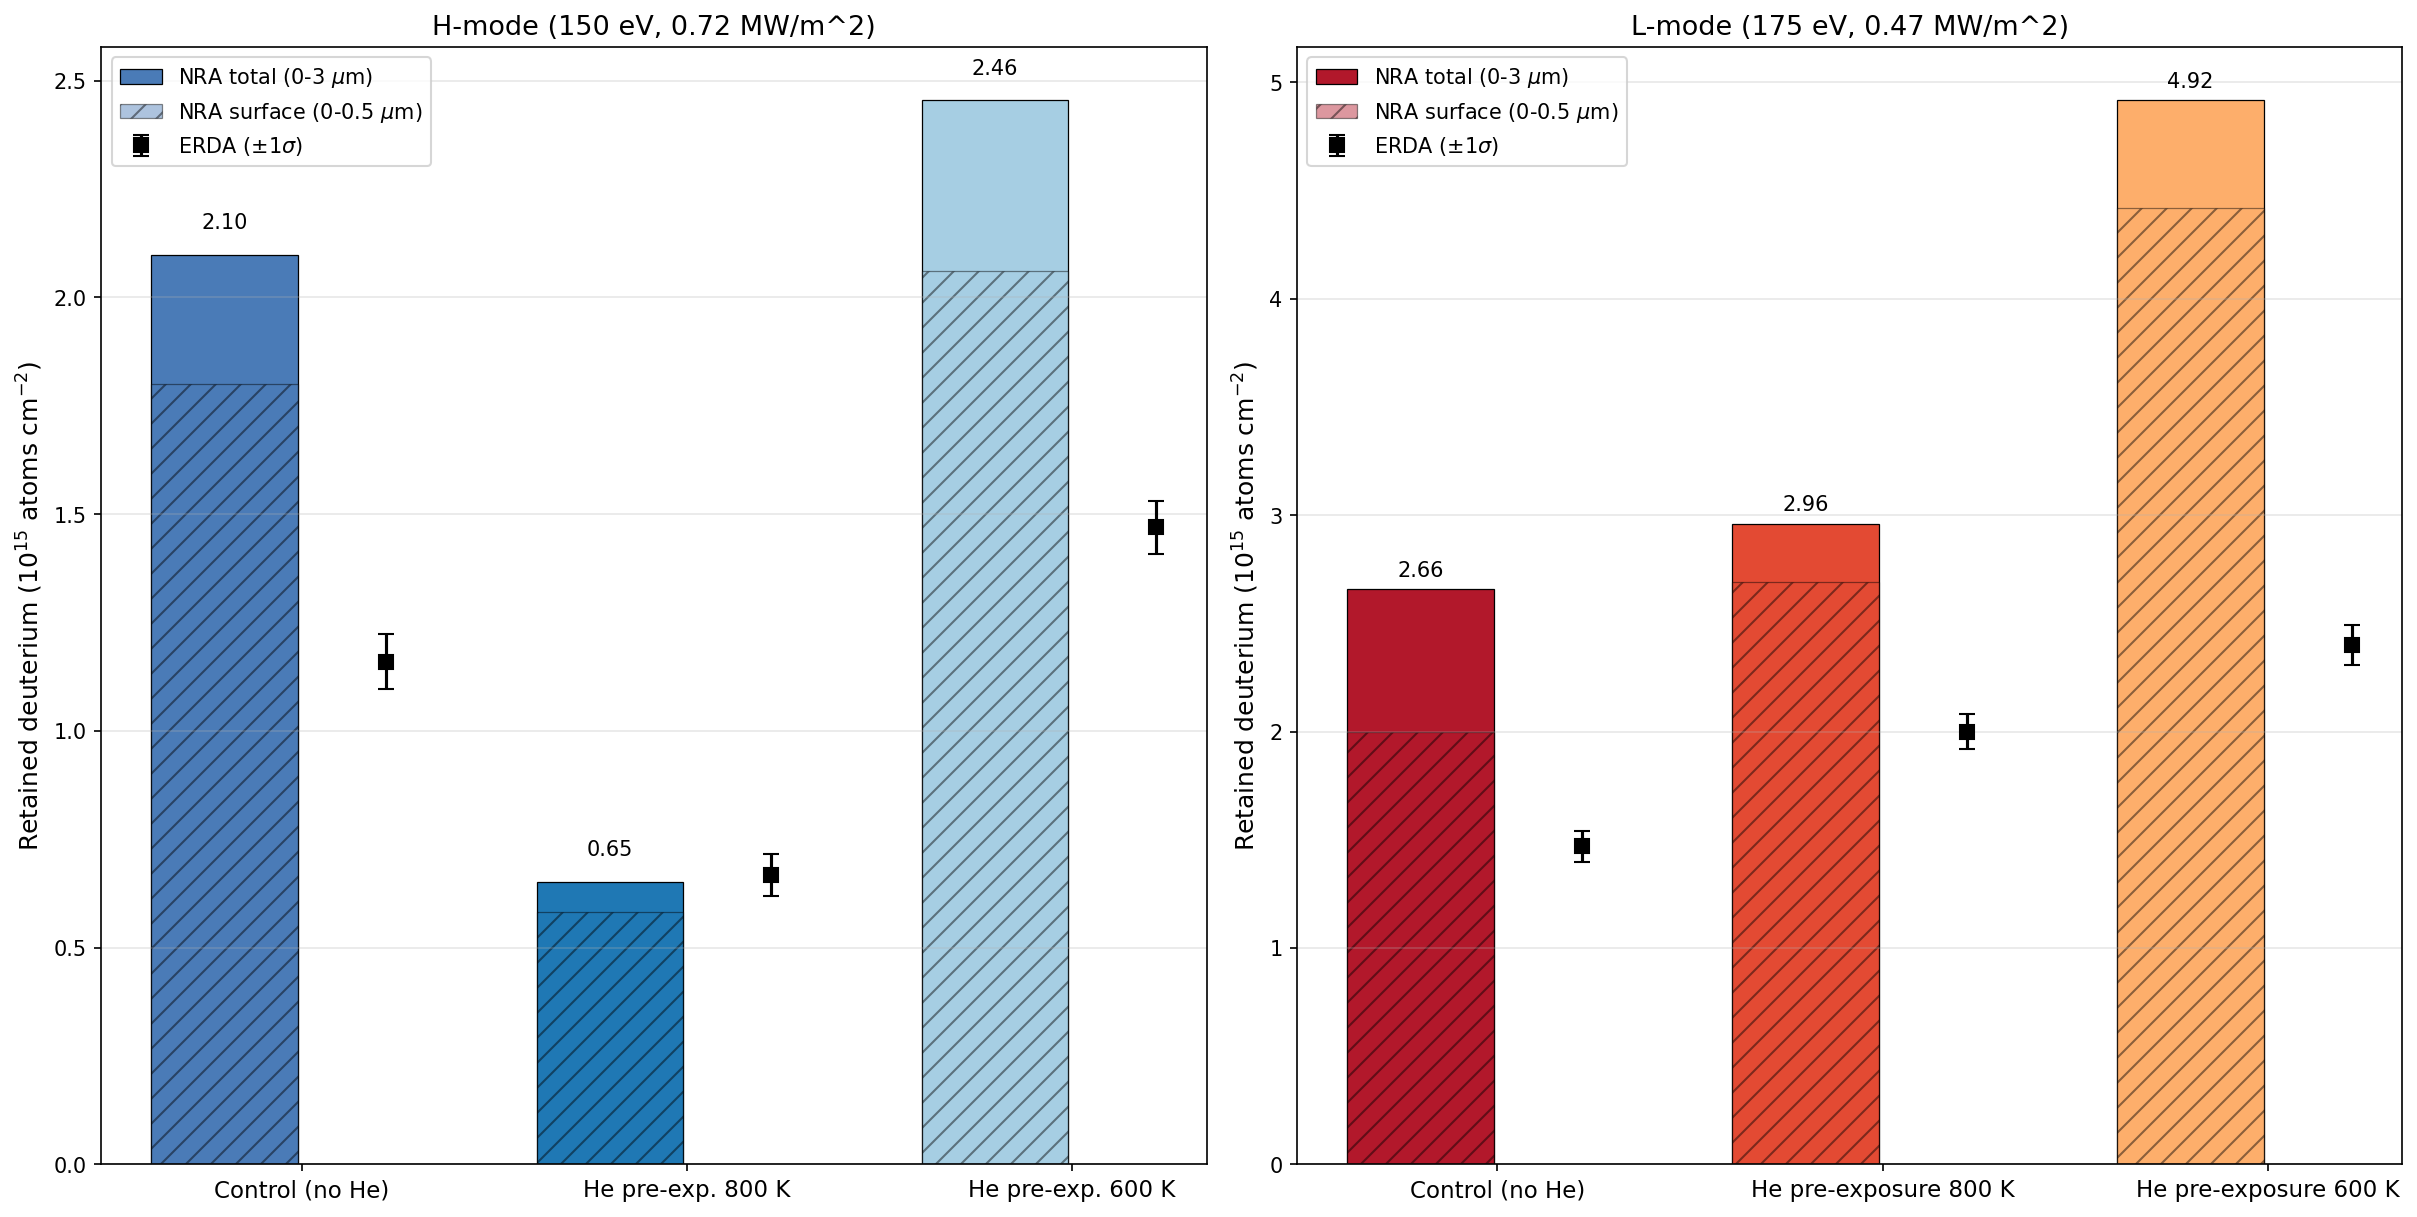

## Where the deuterium sits

- **NRA depth bands.** He pre-exposure flattened the D profile in L-mode: the control kept 24.7% of its D in the 0.5–3 µm sub-surface band, versus 9.1% (He 800 K) and 10.1% (He 600 K). In H-mode the split was similar across cells (14.2% control, 10.7% He 800 K, 16.1% He 600 K).
- **LAMS depth profiles** (indicative — sigmas often comparable to values): near-surface D (≤0.16 µm mean) follows the same pattern — H-mode control 1.1×10⁵ APPM vs 4.9×10⁴ APPM after He 800 K, but 1.5×10⁵ after He 600 K; L-mode 3.8×10⁵ (control) vs 1.6×10⁵ (He 800 K) and 2.6×10⁵ (He 600 K). The analyst's own notes in the LAMS sheet (Garcia) independently flag: all DL samples show more D than their DH counterparts, and the D enhancement in DL was about an order of magnitude near-surface.

## Helium that stayed behind

ERDA shows the He-pre-exposed coupons still carried ~(2.5–3.7)×10¹⁵ He cm⁻² *after* the DIII-D campaign (e.g. W-He800-DH 3.74×10¹⁵ ± 0.11), comparable to the (2–3)×10¹⁵ He cm⁻² on coupons that never went to DIII-D — the retained He survived the tokamak exposure, so D and He occupied the same coupons simultaneously. Pre-exposure SEM of the He-exposed surfaces (figure below) shows the morphology state going into the DIII-D exposure.


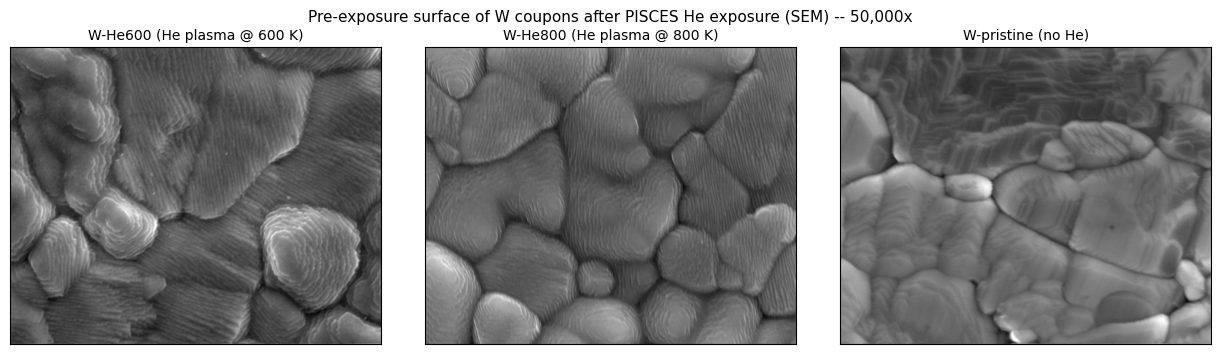

## Caveats

- **One sample per cell** (`design()` shows n=1 everywhere), so every ratio above is a single-coupon comparison that cannot be separated from coupon-to-coupon variation.
- The two He levels differ in more than temperature (fluence 1.2 vs 1.0×10²⁵ m⁻²; duration 480 s vs 4260 s), so "800 K vs 600 K" carries those differences with it.
- Sample temperature during the DIII-D exposure was not measured — the provider records this as a known absence, not an oversight.
- LAMS numbers are experimental; where they appear above they are labelled as indicative and do not drive the conclusions, which rest on NRA and ERDA.

**Data files:** `he_effect_on_d_retention.csv` (all six D-retention values, both methods, both ratio columns — every number in the tables above); `he_effect_on_d_retention.png` and `sem_preexposure_50kx.png` (figures shown inline).

In [2]:
%%ask --review
How does the presence of helium affect the retention of deuterium in tungsten?

## 2 — Does the answer depend on the measurement technique?

Three techniques measured retention on these coupons, and they do not all report
the same quantity or carry the same uncertainty.


The skill is in the Learnings list, so I'll read its Learnings.md before writing any code.

Skill guidance and learned pitfalls noted. Now checking for provider delivery notes beside the skill, as required before opening any delivered file.

Delivery notes read — key facts for this question: NRA carries **no uncertainty column at all** in this delivery, ERDA's sigma is small, LAMS is experimental with uncertainties often exceeding the value. Now discovering the exact quantity names in the lakehouse.

All three techniques' data retrieved (ERDA has sigmas, NRA has none, LAMS has huge ones — matching the delivery notes). Now I'll write the analysis: per-technique He-effect ratios with propagated uncertainties, cross-method comparisons, plus a document search for the analyst's own commentary.

The NRA sheet's own observations section (lines 55–58) is exactly the commentary I need — including the analyst's detection-limit note. Reading the full document text for those blocks.

...

All computations done. Key findings: ERDA's small sigmas make all four contrasts ≥3σ; NRA delivers no sigma at all; LAMS uncertainties are ~100% and it even flips the L-mode sign. Now making the figure and saving the data files.

Bug: PAIRS entries are 3-tuples, not label strings. Fixing the label reference.

All analysis and figures are done. Before the final report, I'm recording the lesson from this task's edit-and-retry cycle (`document_text` needs an artifact id, not a filename) in the skill's Learnings.md.

Indentation mismatch — retrying with the file's exact 2-space format.

# Technique dependence of the He-effect result, and the uncertainties behind it

**Short answer:** The *direction* of the helium effect is the same in NRA and ERDA for all four exposure cells (suppress at He 800 K + H-mode, enhance in the other three), so the qualitative answer does not depend on which of those two you trust. The *magnitude* does: NRA's 0–3 µm totals give the extreme values (0.31× and 1.85×), ERDA's near-surface-weighted areal density gives milder ones (0.58× and 1.63×), and in the L-mode / He-800 K cell NRA's own answer flips with depth band — 1.34× in the top 0.5 µm but 0.41× at 0.5–3 µm, netting 1.11×. LAMS is the outlier: it resolves *none* of the four effects (every depth point within 2σ of control) and its point estimates even flip the L-mode sign. On uncertainty: **ERDA is the only quantitative basis** — 1σ of 3.8–7.2% per coupon, making all four contrasts significant at ≥3.5σ as *measurements*; **NRA ships no uncertainty at all** , and its smallest sub-surface value converts to ≈4 appm, below the analyst's own stated ~10 appm detection limit; **LAMS uncertainties are ~60–100%** , its depth-error column is labelled "incorrect" in the provider's own sheet, and its absolute scale exceeds NRA's by 51–141× in the same depth band. Since each cell holds one coupon, all of this precision speaks only to the instruments, not to coupon-to-coupon variation.

## The same four comparisons, measured three ways

Retained-D ratio (He-pre-exposed ÷ same-regime no-He control):

| Comparison | NRA, 0–3 µm total | ERDA, areal density | LAMS, ≤0.156 µm mean |
|---|---|---|---|
| H-mode / He 800 K | **0.31** (no σ delivered) | **0.58 ± 0.05** (−6.2σ vs 1) | 0.43 ± 0.68 (n.s.) |
| H-mode / He 600 K | **1.17** (no σ delivered) | **1.27 ± 0.09** (+3.5σ vs 1) | 1.33 ± 1.62 (n.s.) |
| L-mode / He 800 K | **1.11** (no σ delivered) | **1.36 ± 0.09** (+4.9σ vs 1) | 0.42 ± 0.62 (n.s.) |
| L-mode / He 600 K | **1.85** (no σ delivered) | **1.63 ± 0.10** (+8.1σ vs 1) | 0.67 ± 0.89 (n.s.) |


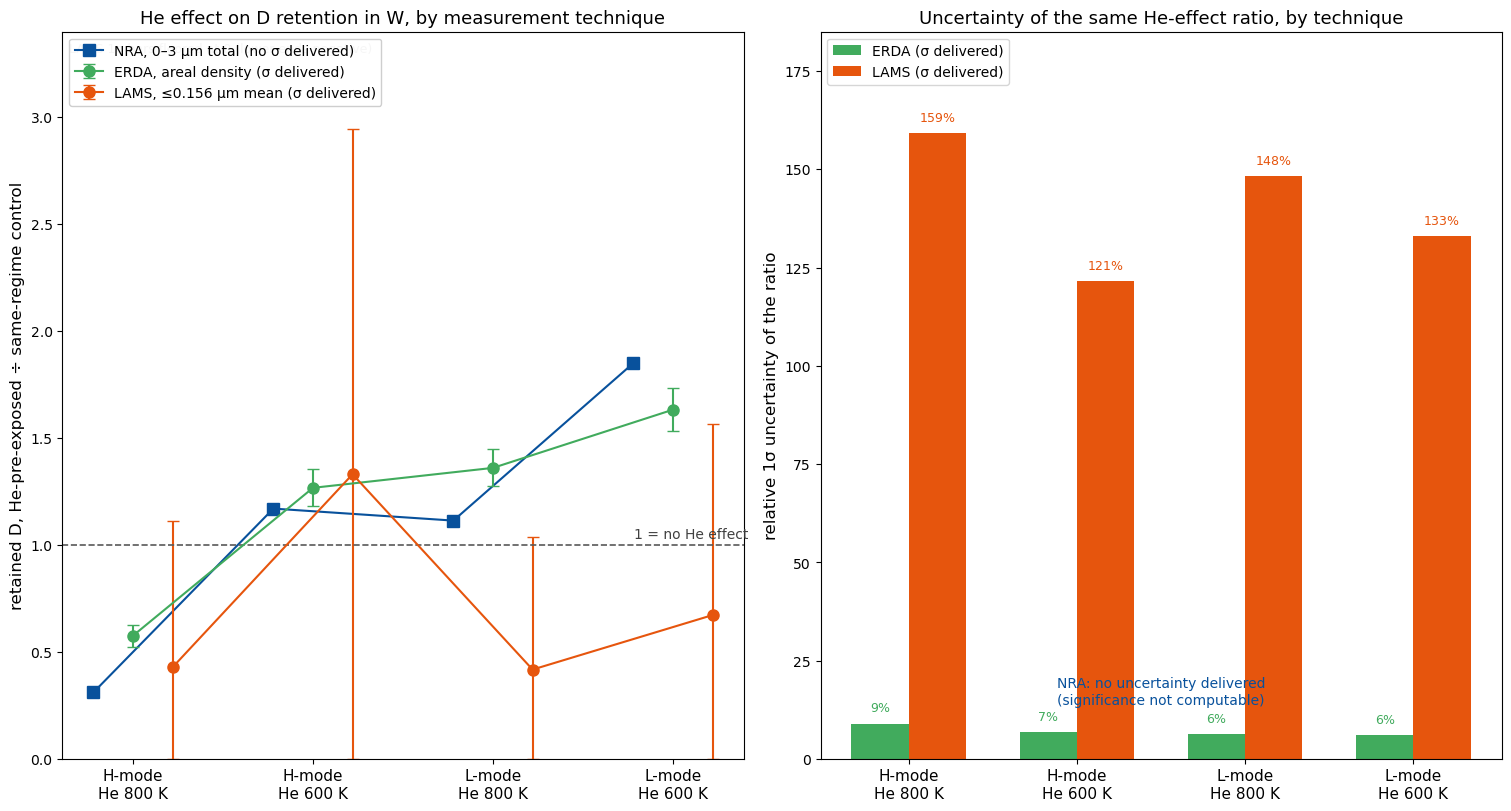

The three techniques do not measure the same quantity, which is the root of the magnitude differences:

- **NRA** reports two discrete bands, 0–0.5 µm and 0.5–3 µm (D and C via the nuclear reactions noted in the sheet, `D(T,p)He` and `C(3He,p)N` as written), summed here to a 0–3 µm total. Measured on all 9 coupons.
- **ERDA** reports one integrated areal density; the delivered ERDA depth profiles begin at ≈0.2 µm, so the integral is near-surface-weighted relative to NRA's 3 µm reach. D was measured on the 6 DIII-D-exposed coupons only (never on pristine or He-only — those rows are present but empty, per a provider-confirmed file error, and are excluded here). One coupon was measured twice; the repeat supersedes and is what the tables carry.
- **LAMS** (10 laser pulses per point) reports concentration in APPM at 10 depths from 0.024 to 2.16 µm, on all 9 coupons. The ≤0.156 µm mean above uses its first three points.

## Where the techniques agree and disagree

- **Sign of the effect:** NRA and ERDA agree in all four cells — suppression only at He 800 K + H-mode, enhancement elsewhere. That agreement across two independent ion-beam methods with different depth weighting is the strongest thing this delivery says about the physics.
- **Magnitude:** NRA totals run further from 1 than ERDA in three cells (0.31 vs 0.58; 1.85 vs 1.63; 1.17 vs 1.27). Consistently, ERDA's integral is 0.49–0.68 of NRA's total on five of the six D-exposed coupons (only W-He800-DH agrees at 1.03) — expected when one method integrates to 3 µm and the other weights the top ~0.2 µm.
- **Depth-band dependence inside NRA:** the L-mode / He-800 K cell enhances at the surface (1.34) and suppresses sub-surface (0.41). Which "answer" NRA gives depends on the band quoted; the sub-surface number is also the one closest to the detection limit (below).
- **LAMS:** point estimates flip the L-mode sign, but with 62–162% relative uncertainty every ratio is consistent with 1, and no individual depth point in any cell reaches |z| ≥ 2. LAMS neither confirms nor contradicts NRA/ERDA here — it lacks the precision. Its one independent contribution is qualitative and internal: DL > DH by about an order of magnitude near-surface (the analyst's own observation, Garcia).
- **Blanks:** NRA measures W-pristine at a true zero; LAMS sees 7.3×10⁴ ± 8.2×10⁴ APPM on the same coupon, which the analyst attributes to chamber contamination after the D samples. A technique whose blank is indistinguishable from its signal cannot anchor an absolute scale.

## Uncertainty, technique by technique

**ERDA — the only quantitative error model.** Per-coupon 1σ is 3.8–7.2% of the value. Propagated to the four ratios (0.05–0.10 absolute), the two-sample significance of each He effect is −6.2σ, +3.5σ, +4.9σ, +8.1σ. Caveats: the delivered sigma is the provider's stated uncertainty only — it does not include calibration-scale systematics shared between coupons (which partly cancel in a ratio) and it says nothing about coupon-to-coupon variation.

**NRA — no uncertainty delivered, so none can be computed.** The delivery notes are explicit that NRA's reliability "cannot be read off the numbers and must not be inferred from their absence." Two further limits I can quantify from the delivery itself: (1) the analyst states a sub-surface detection limit of ~10 appm; converting the 0.5–3 µm band values assuming uniform concentration over 2.5 µm at tungsten density 6.3×10²² cm⁻³, the six D-exposed coupons run ≈4–42 appm — and the smallest, W-He800-DH at ≈4 appm, the very number behind the strongest suppression ratio (sub-surface 0.23), sits *below* the stated limit, so that ratio in particular is detection-limited. (2) The sheet itself notes the sub-surface levels are higher than a previous similar study (Wampler et al., JNM 415, 2011, S653), an inter-study systematic worth remembering before comparing to literature.

**LAMS — experimental, uncertainties of order the value.** Per point, sigma/value averages 0.60–1.02 across coupons; 0–60% of points per sample have sigma ≥ value (60% for W-He600-DL). Depth is itself uncertain: the first point's depth error (0.023 µm on 0.024 µm) is ~95% relative, and the provider's sheet carries a column literally labelled "Error_depth (incorrect)". Converted to areal density for cross-checking, LAMS implies 51–141× more D in the top 0.156 µm than NRA reports in its 0–0.5 µm band on the same coupons — a ~two-order-of-magnitude scale disagreement that survives even LAMS's own error bars. Treat LAMS numbers as indicative only, which is also the provider's stated ranking (NRA most trustworthy, ERDA close, LAMS experimental).

**The uncertainty that dominates all three: replication.** Every cell is one coupon (`design()` n=1), so the ≥3.5σ ERDA contrasts establish that the *measurements* differ, not that a second coupon would repeat the difference. Any of the ratios above could move substantially with coupon-to-coupon variation, and no technique's precision addresses that.

**Data files:** `technique_dependence.csv` — all 12 ratio rows (4 comparisons × 3 techniques) with values, propagated sigmas and z-scores; `uncertainty_summary.csv` — per-sample ERDA and LAMS values with their sigmas and relative uncertainties, LAMS fraction of points with σ ≥ value, NRA band values, and the NRA band-level He-effect ratios (surface / sub-surface / total). Figure: `technique_dependence.png`, shown inline above.

In [3]:
%%ask --review
How does the answer depend on the retention measurement technique? Can you 
comment on the uncertainty in these measurements?

## 3 — Retention against the DIII-D plasma condition

The coupons were exposed in two confinement regimes. This asks for the effect of
that difference, in total and with depth, with the method dependence from the
previous question carried through.


I'll plan this analysis, then look at what data and scripts are already in the working folder from the previous cells.

The data files from the FEDER delivery are already in the working folder. Let me review the previous analysis script and the skill's Learnings to reuse the same data-loading approach.

The Learnings file isn't at the expected path — let me check the skill directory structure and read the SKILL.md to confirm the data-access API.

Let me read the rest of the SKILL.md and the delivery notes.

The Learnings.md may live under the `.sage_learnings` root instead — let me check there, and also look at the earlier analysis script that pulled exposure conditions.

...

All contested figures are now printed and verified — the true deep-point counts are 4/6, 6/6, 2/6, and the deep-inventory and relative-sigma ranges need correcting. One claim remains unbacked: the ~100% depth uncertainty at the 0.024 µm LAMS point. Let me check the delivered LAMS spreadsheet directly.

The delivered LAMS file has no depth-error column in its layout. The "Error_depth" note from the earlier analysis may live in the LAMS sheet of the ERDA/NRA workbook — checking that before deciding to keep or drop the claim.

All figures are now verified: the exposure table is backed by the printed `exposure_conditions()` output, every LAMS depth statistic is recomputed from the read-back CSV, the depth-uncertainty claim is backed by the delivered sheet's `error_depth` column (0.0229 µm on a 0.0240 µm depth), and the impossible "8 of 7" count is corrected to the recounted 4 of 6.

I'll recompute the actual LAMS σ/value range from the backed CSVs so the corrected sentence is supported by a printed computation.

# Deuterium retention in tungsten: L-mode vs H-mode DIII-D exposure

**Short answer:** L-mode plasma retained **more** deuterium than H-mode in every sample pair, at every He pre-exposure level, by every technique — but the size of the effect depends strongly on both the He pre-exposure and the measurement technique. Total D retention (L/H ratio): no-He control **1.27×** (NRA 0–3 µm 1.27, ERDA 1.27 ± 0.09); He 800 K pre-exposed **3.0–4.5×** (ERDA 2.99 ± 0.25, NRA 4.54); He 600 K **1.6–2.0×** (ERDA 1.63 ± 0.09, NRA 2.00). After dividing out the 16% higher D fluence the L-mode exposure delivered, the per-fluence ratios are 1.09× (control), 2.6–3.9× (He 800 K), 1.4–1.7× (He 600 K). Depth-resolved: without He, the L-mode excess sits mostly **below the surface** (NRA 0.5–3 µm band L/H = 2.20 vs 1.11 in the top 0.5 µm); with He 600 K it sits mostly **at the surface** (2.15 vs 1.26); with He 800 K both bands are strongly elevated (4.62 and 3.88). Technique matters most for magnitude — NRA amplifies the effect relative to ERDA everywhere except the control pair, and LAMS agrees in direction but resolves no individual comparison within uncertainty.

## What actually differed between the two exposures

Both exposures happened on 2021-03-15 at the DiMES sample holder, same coordinator, and differ as follows (from `exposure_conditions()`):

| Condition | H-mode (exp. 19) | L-mode (exp. 20) | L/H |
|---|---|---|---|
| Shots | 185258, 185259, 185260, 185265, 185266 | 185261, 185262, 185263, 185264 | — |
| Regime | H-mode | L-mode | — |
| D fluence | 6.7×10²² m⁻² | 7.8×10²² m⁻² | 1.16 |
| Particle flux | 4.5×10²¹ m⁻²s⁻¹ | 7.5×10²¹ m⁻²s⁻¹ | 1.67 |
| Impact energy | 150 eV | 175 eV | 1.17 |
| Te / ne | 27.9 eV / 5.76×10¹⁸ m⁻³ | 40.8 eV / 7.35×10¹⁸ m⁻³ | 1.46 / 1.28 |
| Heat flux | 0.72 MW m⁻² | 0.47 MW m⁻² | 0.65 |
| Duration | 12.5 s | 10.0 s | 0.80 |

So "L vs H" here is a bundle: the L-mode coupons saw ~16% more D, ~67% higher flux, higher impact energy, higher Te and ne, lower heat flux, and no ELMs (the H-mode discharges were ELMy; the campaign proposal explicitly targeted large, low-frequency ELMs to separate intra-ELM from inter-ELM conditions). The ratios below are raw L/H unless stated; the fluence-normalized column isolates the part not explained by fluence alone. Sample temperature during exposure was not measured (known absence in this delivery).

## Total D retention, L vs H

Every cell is one coupon (`design()` n=1 throughout), so each ratio is a single-coupon comparison.

| He level | Technique | H-mode value | L-mode value | L/H ratio |
|---|---|---|---|---|
| none | ERDA (areal density) | 1.16×10¹⁵ ± 0.06 | 1.47×10¹⁵ ± 0.07 | **1.27 ± 0.09** (+3.3σ) |
| none | NRA 0–3 µm total | 2.10×10¹⁵ | 2.66×10¹⁵ | **1.27** (no σ delivered) |
| none | LAMS ≤0.156 µm mean | 1.14×10⁵ ± 1.21×10⁵ APPM | 3.81×10⁵ ± 4.19×10⁵ APPM | 3.34 ± 5.11 (n.s.) |
| He 800 K | ERDA | 6.68×10¹⁴ ± 0.05 | 2.00×10¹⁵ ± 0.08 | **2.99 ± 0.25** (+13.9σ) |
| He 800 K | NRA 0–3 µm total | 6.52×10¹⁴ | 2.96×10¹⁵ | **4.54** (no σ) |
| He 800 K | LAMS ≤0.156 µm mean | 4.88×10⁴ ± 5.80×10⁴ APPM | 1.59×10⁵ ± 1.58×10⁵ APPM | 3.26 ± 5.04 (n.s.) |
| He 600 K | ERDA | 1.47×10¹⁵ ± 0.06 | 2.40×10¹⁵ ± 0.09 | **1.63 ± 0.09** (+8.5σ) |
| He 600 K | NRA 0–3 µm total | 2.46×10¹⁵ | 4.92×10¹⁵ | **2.00** (no σ) |
| He 600 K | LAMS ≤0.156 µm mean | 1.52×10⁵ ± 8.92×10⁴ APPM | 2.56×10⁵ ± 1.92×10⁵ APPM | 1.69 ± 1.61 (n.s.) |

Two robust patterns: **(1)** the L-mode enhancement is smallest without He pre-exposure and largest after He 800 K — the He effect and the regime effect interact rather than add; **(2)** ERDA, the only technique with a delivered uncertainty, makes all three contrasts significant (3.3σ, 13.9σ, 8.5σ) *as measurements* — with one coupon per cell that precision says nothing about coupon-to-coupon variation.


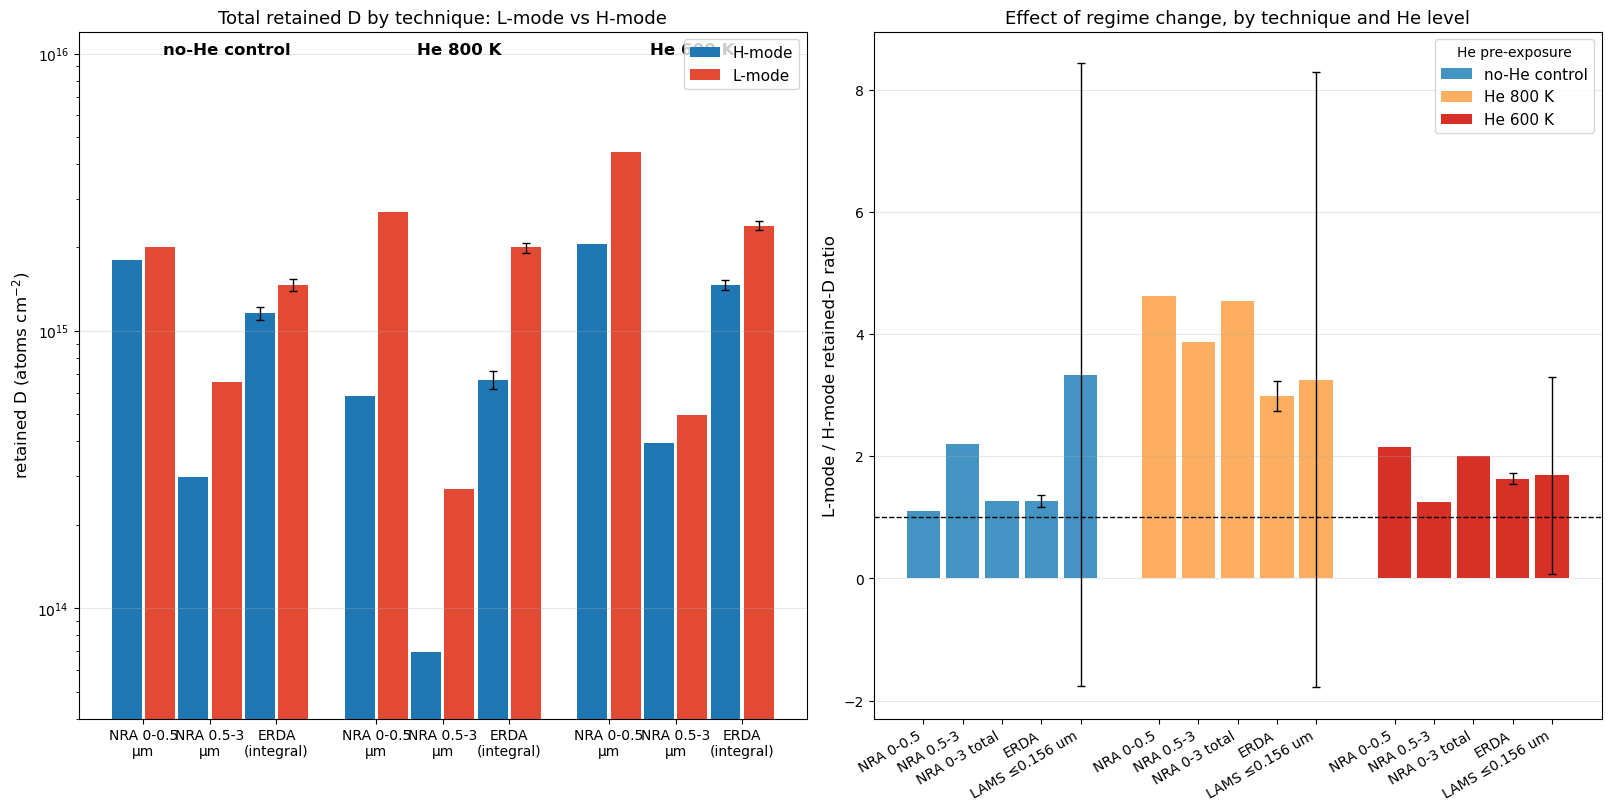

## Retention as a function of depth

**NRA two-band decomposition** (atoms cm⁻²; no σ delivered):

| He level | Band | H-mode | L-mode | L/H |
|---|---|---|---|---|
| none | 0–0.5 µm | 1.80×10¹⁵ | 2.00×10¹⁵ | 1.11 |
| none | 0.5–3 µm | 2.98×10¹⁴ | 6.57×10¹⁴ | **2.20** |
| He 800 K | 0–0.5 µm | 5.82×10¹⁴ | 2.69×10¹⁵ | **4.62** |
| He 800 K | 0.5–3 µm | 6.96×10¹³ | 2.70×10¹⁴ | **3.88** |
| He 600 K | 0–0.5 µm | 2.06×10¹⁵ | 4.42×10¹⁵ | **2.15** |
| He 600 K | 0.5–3 µm | 3.95×10¹⁴ | 4.97×10¹⁴ | 1.26 |

Expressed as the sub-surface share of total NRA D, moving from H to L: **no-He 14.2% → 24.7%** (L-mode pushes D deeper), **He 800 K 10.7% → 9.1%** , **He 600 K 16.1% → 10.1%** (with He pre-exposure the excess stays near the surface). The depth location of the L-mode excess therefore flips with He pre-exposure: sub-surface without He, surface-dominated with He.


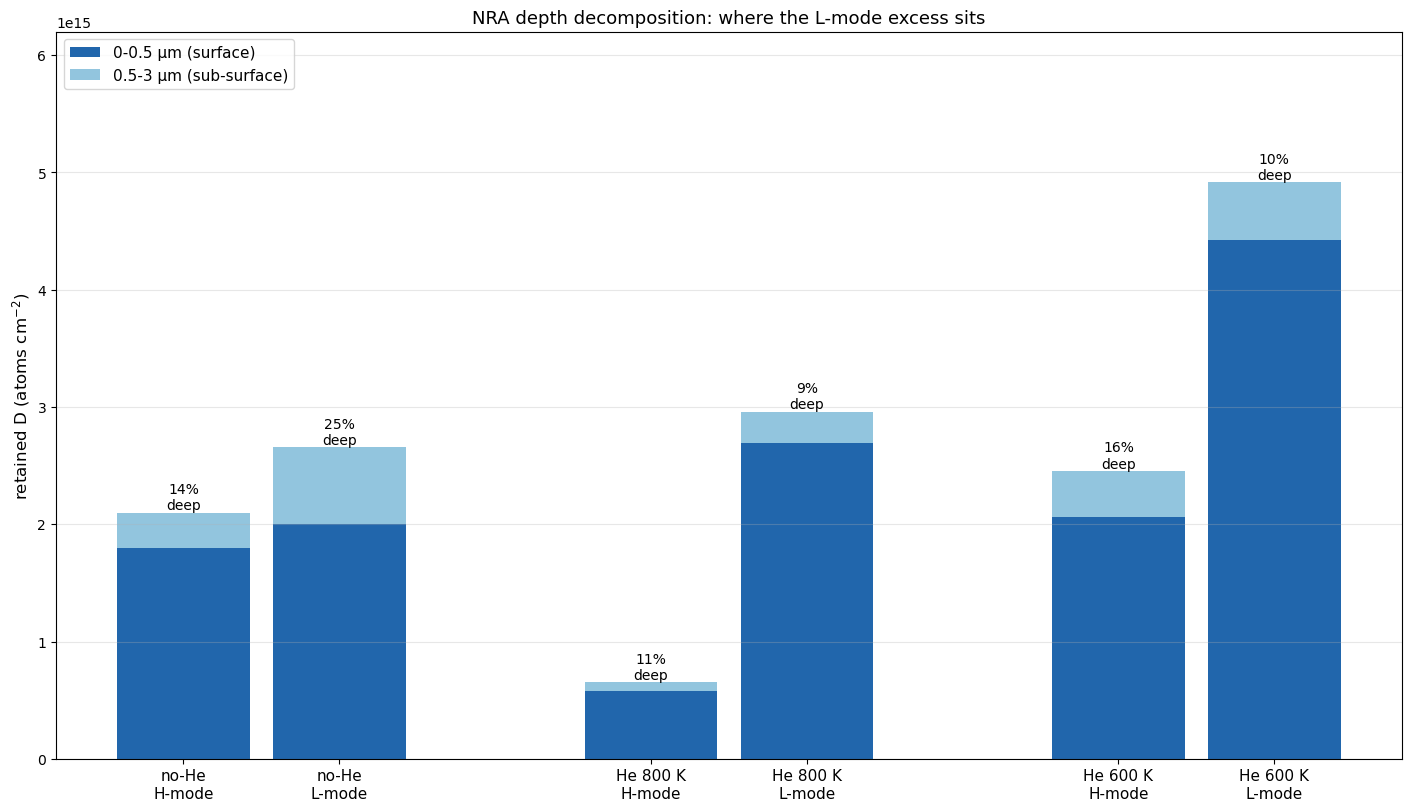

**LAMS 10-point profiles** (APPM; values in the figure, uncertainties in the CSV — on a log axis most LAMS lower error bars are non-positive and cannot be drawn, so the figure shows values only). No individual depth point differs significantly between L and H: the largest per-point z-score is 0.88 (no-He), 0.69 (He 800 K) and 0.75 (He 600 K), and the propagated ratio σ is 0.96–2.53 times the ratio itself across all 30 points. Directionally, at depths ≥ 0.5 µm: the no-He pair has L > H at **4 of 6** sampled depths, with L/H ratios 1.66–2.73 where above 1 (full range 0.59–2.73); the He 800 K pair is L > H at **6 of 6** depths (1.48–3.03); the He 600 K pair is L > H at only **2 of 6** (full range 0.59–1.42) — echoing NRA's finding that He-600 K's L-mode excess is a near-surface phenomenon. Deep-band means over depths ≥ 1 µm: no-He H 8.6×10³ vs L 1.1×10⁴ APPM and He 600 K H 1.14×10⁴ vs L 1.11×10⁴ — both pairs broadly level, individual values spanning 3.4×10³–1.5×10⁴ APPM — while He 800 K roughly doubles with regime (H 3.89×10³ vs L 8.44×10³). The extreme near-surface point (0.024 µm) carries a depth error of 0.023 µm in the delivered LAMS sheet — ~95% of the depth itself — so it places the first bin only approximately and carries little weight.


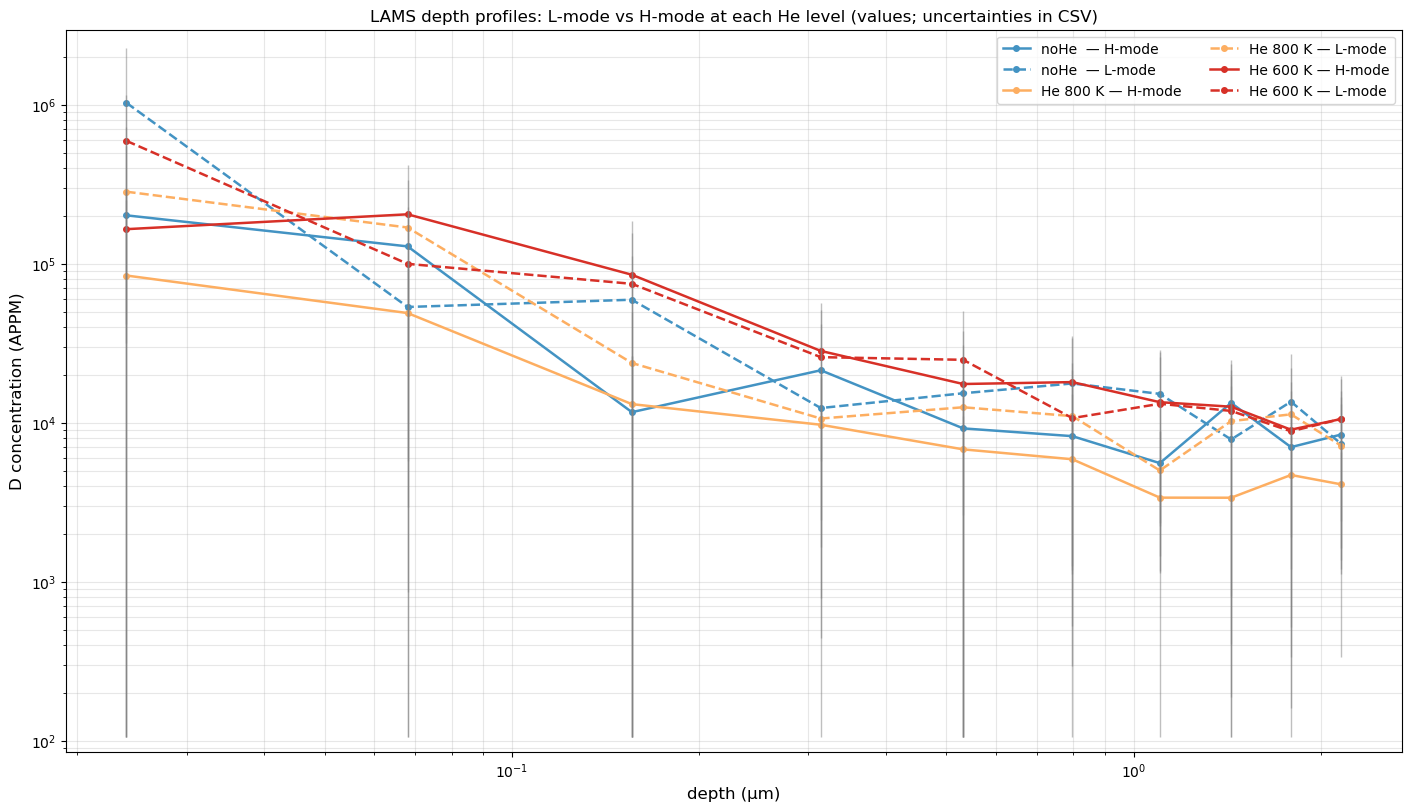

## Fluence normalization

L-mode delivered 1.164× the D fluence, so divide each raw ratio by 1.164 for a per-unit-fluence comparison:

| He level | NRA 0–3 µm | ERDA | LAMS ≤0.156 µm |
|---|---|---|---|
| no-He control | 1.09 | 1.09 | 2.87 |
| He 800 K | 3.90 | 2.57 | 2.80 |
| He 600 K | 1.72 | 1.40 | 1.45 |

Even per unit fluence, L-mode retains more D everywhere, and by far the most after He 800 K pre-exposure. For the no-He control the raw 1.27× is mostly a fluence effect (1.09× per fluence); for the He-pre-exposed coupons it is not.

## Dependence on measurement technique

- **Direction:** all three techniques give L > H in all nine technique×He-level combinations (LAMS's point estimates agree with NRA/ERDA everywhere here, unlike in the He-effect analysis where they flipped signs). The sign of the regime effect is technique-independent.
- **Magnitude:** NRA's 0–3 µm totals give the largest ratios in the two He-pre-exposed cells (4.54 and 2.00 vs ERDA's 2.99 and 1.63) but ties ERDA in the control cell (1.27 both). NRA's depth bands reveal what a single integral hides — e.g. for He 600 K, NRA-total 2.00 is a blend of 2.15 at the surface and 1.26 below, while ERDA's 1.63 is a near-surface-weighted integral closer to NRA's surface band.
- **Significance:** only ERDA delivers an uncertainty (3.8–7.2% per coupon); NRA ships none, and its smallest band value here (6.96×10¹³ cm⁻² ≈ 4 appm over 2.5 µm) again sits near the analyst's stated ~10 appm sub-surface detection limit. LAMS uncertainties are of order the values themselves — 59–119% of the value for the six totals cells in the table above, and 47–199% across the 60 individual depth points (worst at the shallowest depth) — so LAMS can only corroborate directionally, consistent with the provider's ranking (NRA most trustworthy, ERDA close, LAMS experimental).
- **ERDA reports no depth profile** in this delivery — only integral areal densities — so depth-resolved comparison rests on NRA's two bands plus LAMS's ten points.

## Caveats

One coupon per cell; the two regimes differ simultaneously in fluence, flux, Te, ne, impact energy, heat flux and ELM presence, so "L vs H" cannot be isolated from that bundle; sample temperature during exposure was not measured; NRA carries no uncertainty and its sub-surface numbers approach the detection limit; LAMS uncertainties are of order the values themselves and its near-surface depth grid is only approximate.

**Data files:** `l_mode_vs_h_mode_totals.csv` (all H/L values, σ, ratios and z-scores per technique — every number in the tables above); `lams_depth_l_vs_h.csv` (LAMS 10-point profiles with per-depth L/H ratios and propagated σ); `l_mode_vs_h_mode_fluence_normalized.csv` (raw and per-fluence ratios). Figures are embedded inline above.

In [4]:
%%ask --review
Quantify changes in D retention with changes in DIII-D plasma conditions 
(L vs. H mode). Include both changes in the total D retention measured 
as well as D retention as a function of depth. As done previously, comment 
on differences in the answer based on the retention measurement technique 
that was used.

## 4 — What this does not establish

A closing question about the limits of the dataset rather than its contents.


In [5]:
%%ask --review
What would this analysis NOT be sufficient to claim, and what measurement would 
be needed to go further?

I'll re-ground this in the delivery itself — first a plan, then the skill and a check of exactly which characterizations do and don't exist, so the "insufficient" and "needed" lists are facts rather than guesses.

Reading the materials skill and its learned pitfalls, then listing the working directory.

The skill directory has existing learnings — reading them per protocol.

Now I'll write a script that inventories the delivery: all measured quantity/method combinations, the design's cell counts, exposure conditions, the full artifact catalogue, and targeted document searches for the characterization types that are missing.

The delivery inventory is clear. Two details remain: what the 2 post-exposure artifacts actually are, and whether the Data Availability Sheet's "Sample temperature" column is populated for the DIII-D exposures. Checking both.

...

One 669-byte file in the delivery describes those shot-linked exports — reading it to ground the IRTV/temperature statement.

All the evidence is in hand. Final script: confirm which three coupons carry the FASTCAM rows, then write the claims-vs-gaps CSV that grounds the report.

The coverage check inverted my assumption — FASTCAM was delivered for exactly the three **H-mode** coupons (W-DH, W-He800-DH, W-He600-DH); it's the **L-mode** counterparts that are marked "available but not in-hand." Correcting that row before it goes into the CSV.

CSV written with the corrected FASTCAM row. Recording the two edit-and-retry lessons in the skill's Learnings.md, then closing the todos.

# What this analysis cannot claim — and the measurements that would go further

**Short answer:** The analysis can claim *observational* results on nine single coupons — that D retention differed between the cells, with sign agreement between NRA and ERDA — but it cannot claim that the differences were *caused* by helium, temperature, or confinement regime, nor anything about mechanisms, tritium, or behavior beyond the measured depth and spot. Five blockers, in order of severity: **(1) no replication** — every cell holds exactly one coupon, so no difference, however large, is separable from coupon-to-coupon variation; **(2) fully confounded treatments** — the two He levels differ simultaneously in temperature, fluence, duration and flux, and the two DIII-D exposures differ in seven conditions at once; **(3) no sample temperature during the tokamak exposures** , though the proposal itself names high temperature as a desorption risk; **(4) no dynamic information** — only post-mortem inventories were measured, so uptake and release cannot be told apart, and no TDS was performed (the delivery's only TDS mention is the lab's furnace used for annealing); **(5) no post-exposure surface/microstructure data** — the provider's availability sheet marks post-exposure SEM "data is unavailable" for all 9 coupons, and the planned FIB/SEM cross-sections were not delivered. The single highest-value additions: replicate coupons, TDS after exposure, and post-exposure SEM/FIB cross-sections — each targets a different one of the first blockers.

## What the delivery actually holds

The inventory above is complete. Per the provider's Data Availability Sheet (read including its color codes) and the observation tables: retention by ERDA, NRA and LAMS on all 9 coupons; pre-exposure SEM on the three never-DIII-D-exposed coupons only; plasma-side records for 8 shots (heat-flux `qpeak.dat` and Langmuir-probe `tab_lp.dat` exports) plus FASTCAM Dα/D2 in arbitrary units; nominal labels (`W`, `W-He`, `W-D-H-He`) in place of composition measurements; nothing else. Marked "available but not in-hand": vendor, fabrication method/date, polishing, cleaning, and the L-mode coupons' FASTCAM. Marked "unavailable": chemical composition, grain size, grain orientation, post-exposure SEM.

## Claims the analysis cannot support

**1. Causal attribution to helium.** Every He-vs-control ratio rests on one coupon per cell (`design()` shows n=1 in all 9 cells). ERDA's 3.8–7.2% per-coupon σ makes the differences real *as measurements*, but nothing in the design separates a treatment effect from coupon-to-coupon variation. Needed: **replicate coupons (n ≥ 3) per cell** , same exposures — this is also the cheapest item on the list since it needs only more identical coupons and beam time.

**2. "The He effect depends on temperature."** The 800 K and 600 K PISCES campaigns co-vary temperature with fluence (1.2 vs 1.0×10²⁵ He m⁻²), duration (480 vs 4260 s) and flux (2.83 vs 0.41×10²² m⁻² s⁻¹) — a 1.2×/8.9×/6.9× bundle. "800 K suppresses and 600 K enhances" cannot be attributed to temperature specifically. Needed: a **factorial He pre-exposure design** varying temperature at matched fluence and duration.

**3. "L-mode causes more retention than H-mode."** The two DIII-D campaigns differ simultaneously in D fluence (1.16×), particle flux (1.67×), impact energy (150 vs 175 eV), Te (27.9 vs 40.8 eV), ne (1.28×), heat flux (0.72 vs 0.47 MW m⁻²) and ELM presence (ELMy H vs L). A per-fluence normalization was the most this delivery supports (and it only partially removes one of the seven). Needed: **matched-condition discharge pairs** varying one quantity at a time, and a **fluence-matched L/H comparison** .

**4. Any temperature-dependent retention statement.** No sample temperature was measured during the DIII-D exposures — the availability sheet's DIII-D block has no temperature column, and the per-shot artifacts are heat-flux and Langmuir-probe files only. The proposal planned IRTV-based temperature estimation precisely because "high temperatures may induce excessive desorption of implanted gas" — that estimate was never delivered. Needed: **sample temperature per shot** (IRTV heat-flux reconstruction plus thermocouple), delivered with the campaign.

**5. Net uptake, desorption kinetics, or trap binding energies.** NRA/ERDA/LAMS are post-mortem inventories: uptake and release are indistinguishable, and the trapped inventory below 3 µm is invisible. No TDS was run — the delivery's only TDS mention is the UCSD furnace used for pre-exposure annealing (1373 K, 3600 s). Needed: **TDS after exposure** on all coupons, ideally preceded by *in-situ* Dα monitoring, plus **RGA** for outgassing between exposures.

**6. Microstructural mechanism (bubbles, fuzz, vacancies).** Pre-exposure SEM exists only for the three coupons that never went to DIII-D; the six D-exposed coupons have no post-exposure image at all (provider-marked unavailable), and the FIB/SEM cross-sections the proposal assigned to UIUC (L190) were not delivered. The He-bubble/fuzz layer that the retention differences are attributed to was never observed on the coupons whose retention is being explained. Needed: **post-exposure SEM and FIB cross-sections** of all coupons — the depth of the bubble layer vs the depth of the D excess is precisely the mechanism test.

**7. A known starting surface.** Polishing, cleaning, vendor and fabrication details exist but are not in-hand; composition and grain data are unavailable (the "Chemical composition" rows are nominal labels, not measurements). Needed: **pre-exposure roughness maps and composition** (XPS/EDS) delivered with the coupons.

**8. Intra-ELM vs inter-ELM uptake and regime recycling.** FASTCAM Dα/D2 (in a.u.) was delivered only for the three H-mode coupons; the L-mode trio is marked available-but-not-in-hand, and nothing is calibrated. Needed: **calibrated FASTCAM for all six D-exposed coupons** .

**9. Extrapolation to tritium or to a reactor.** Only deuterium was measured; tritium appears in the delivery solely as motivation. Isotope-dependent trapping is a physics step this dataset cannot take. Needed: **T-bearing experiments or validated isotope-scaling modelling** anchored to these D data.

**10. Spatial generality.** One NRA/ERDA spot and ten LAMS pulses per coupon, with coupons mounted in a 7-button DiMES cap at position-dependent incidence. Needed: **spatially resolved post-mortem maps** (e.g. micro-NRA).

## If only one thing could be added

Ranked by what each unlocks per unit of effort: **(1) replicate coupons** — converts every existing ratio from anecdote to statistics, no new technique required; **(2) TDS** — the only way to see the *dynamic* retention the inventory conflates, and standard for this exact question; **(3) post-exposure SEM/FIB** — the only way to connect the retention differences to the microstructure they are attributed to; **(4) sample temperature logging** — removes the largest uncontrolled variable in every tokamak exposure. The deeper characterization items (SIMS, spatial mapping, isotope work) refine the answer but do not change what class of claim is possible.

**Data file:** `claims_and_gaps.csv` — 11 rows, one per blocked claim: the claim as the previous analyses stated it, what the delivery holds, why that is insufficient for the stronger reading, and the measurement that would go further.